In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

from afolu.assets.constants import LABEL_LIST
from afolu.assets.emissions import build_dataset, generate_model_objects
from pathlib import Path

/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/munch/__init__.py:24: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
data_path = Path(os.environ["DATA_PATH"])
out_path = data_path / "generated"

In [3]:
ZONE = "PER+Coronel Portillo"

In [4]:
df_out = pd.read_csv(out_path / "small" / "emissions" / f"{ZONE}.csv").query("time_period < 21").set_index("time_period")

In [5]:
areas = pd.read_csv(out_path / "small" / "area" / "table_merged" / f"{ZONE}.csv")
transitions = pd.read_csv(out_path / "small" / "transition" / "cube" / f"{ZONE}.csv")
transitions_emissions = pd.read_csv(out_path / "small" / "transitions_emissions" / f"{ZONE}.csv").query("time_period < 21")

In [6]:
def emissions_small(
    areas: pd.DataFrame,
    transitions: pd.DataFrame,
    *,
    iso: str
) -> pd.DataFrame:
    # Initialize SISEPUEDE objects
    examples, _, model_afolu, regions, time_periods = generate_model_objects()

    temp = areas.set_index("label")

    areas_frac = (
        temp
        .div(temp.sum(axis=0), axis=1)
        .reset_index(names="label")
    )

    # run model
    dict_ursa_data = {
        "areas": areas,
        "areas_frac": areas_frac,
        "transitions": transitions,
    }
    df_in = build_dataset(
        examples,
        iso,
        model_afolu,
        regions,
        time_periods,
        dict_ursa_data=dict_ursa_data,
        path_ssp_data=data_path / "initial" / "sisepuede_pipeline_data",
    )

    return model_afolu(
        df_in,
    ).set_index("time_period")

In [7]:
positive_lands = ["croplands", "forests_mangroves", "forests_primary", "forests_secondary", "flooded", "grasslands", "pastures", "shrublands", "wetlands"]
negative_lands = list(set(LABEL_LIST) - set(positive_lands))

In [8]:
positive_max = areas.set_index("label").loc[[idx for idx in positive_lands if idx in areas["label"].values]].max(axis=1)
negative_min = areas.set_index("label").loc[[idx for idx in negative_lands if idx in areas["label"].values]].min(axis=1)
best = pd.concat([positive_max, negative_min])

areas_dummy = pd.concat([best.rename(str(i)) for i in range(23)], axis=1).sort_index().reset_index()

In [9]:
transitions_dummy = transitions.copy()
for start_label in LABEL_LIST:
    for end_label in LABEL_LIST:
        col_name = f"pij_lndu_{start_label}_to_{end_label}"
        if start_label == end_label:
            transitions_dummy[col_name] = 1.
        else:
            transitions_dummy[col_name] = 0.

In [24]:
transitions_dummy["time_period"]

0      0
1      1
2      2
3      3
4      4
5      5
6      6
7      7
8      8
9      9
10    10
11    11
12    12
13    13
14    14
15    15
16    16
17    17
18    18
19    19
20    20
21    21
Name: time_period, dtype: int64

In [ ]:
areas_dummy

,label,0,1,2,3,4,5,6,7,8,...,13,14,15,16,17,18,19,20,21,22
0,croplands,609.747682,609.747682,609.747682,609.747682,609.747682,609.747682,609.747682,609.747682,609.747682,...,609.747682,609.747682,609.747682,609.747682,609.747682,609.747682,609.747682,609.747682,609.747682,609.747682
1,flooded,5637.064288,5637.064288,5637.064288,5637.064288,5637.064288,5637.064288,5637.064288,5637.064288,5637.064288,...,5637.064288,5637.064288,5637.064288,5637.064288,5637.064288,5637.064288,5637.064288,5637.064288,5637.064288,5637.064288
2,forests_primary,8203.356057,8203.356057,8203.356057,8203.356057,8203.356057,8203.356057,8203.356057,8203.356057,8203.356057,...,8203.356057,8203.356057,8203.356057,8203.356057,8203.356057,8203.356057,8203.356057,8203.356057,8203.356057,8203.356057
3,forests_secondary,50313.600406,50313.600406,50313.600406,50313.600406,50313.600406,50313.600406,50313.600406,50313.600406,50313.600406,...,50313.600406,50313.600406,50313.600406,50313.600406,50313.600406,50313.600406,50313.600406,50313.600406,50313.600406,50313.600406
4,grasslands,24.153058,24.153058,24.153058,24.153058,24.153058,24.153058,24.153058,24.153058,24.153058,...,24.153058,24.153058,24.153058,24.153058,24.153058,24.153058,24.153058,24.153058,24.153058,24.153058
5,other,91.567003,91.567003,91.567003,91.567003,91.567003,91.567003,91.567003,91.567003,91.567003,...,91.567003,91.567003,91.567003,91.567003,91.567003,91.567003,91.567003,91.567003,91.567003,91.567003
6,pastures,7195.799962,7195.799962,7195.799962,7195.799962,7195.799962,7195.799962,7195.799962,7195.799962,7195.799962,...,7195.799962,7195.799962,7195.799962,7195.799962,7195.799962,7195.799962,7195.799962,7195.799962,7195.799962,7195.799962
7,settlements,4624.285240,4624.285240,4624.285240,4624.285240,4624.285240,4624.285240,4624.285240,4624.285240,4624.285240,...,4624.285240,4624.285240,4624.285240,4624.285240,4624.285240,4624.285240,4624.285240,4624.285240,4624.285240,4624.285240
8,shrublands,570.906636,570.906636,570.906636,570.906636,570.906636,570.906636,570.906636,570.906636,570.906636,...,570.906636,570.906636,570.906636,570.906636,570.906636,570.906636,570.906636,570.906636,570.906636,570.906636
9,wetlands,24736.909673,24736.909673,24736.909673,24736.909673,24736.909673,24736.909673,24736.909673,24736.909673,24736.909673,...,24736.909673,24736.909673,24736.909673,24736.909673,24736.909673,24736.909673,24736.909673,24736.909673,24736.909673,24736.909673


In [11]:
%%capture

df_dummy = emissions_small(areas_dummy, transitions_dummy, iso=ZONE.split("+")[0])
df_dummy = df_dummy.iloc[:21].copy()

In [12]:
sequestration_columns = [
    "emission_co2e_co2_lndu_biomass_sequestration_grasslands",
    "emission_co2e_co2_lndu_biomass_sequestration_other",
    "emission_co2e_co2_lndu_biomass_sequestration_pastures",
    "emission_co2e_co2_lndu_biomass_sequestration_settlements",
    "emission_co2e_co2_lndu_biomass_sequestration_shrublands",
    "emission_co2e_co2_lndu_biomass_sequestration_wetlands",
    "emission_co2e_subsector_total_frst"
]

In [13]:
ideal_sequestration = df_dummy[sequestration_columns].sum(axis=1).abs()
actual_sequestration = df_out[sequestration_columns].sum(axis=1).abs()

sequestration_oppportunity_cost = ideal_sequestration - actual_sequestration
sequestration_oppportunity_cost.index = (sequestration_oppportunity_cost.index + 2000).astype(int).astype(str)

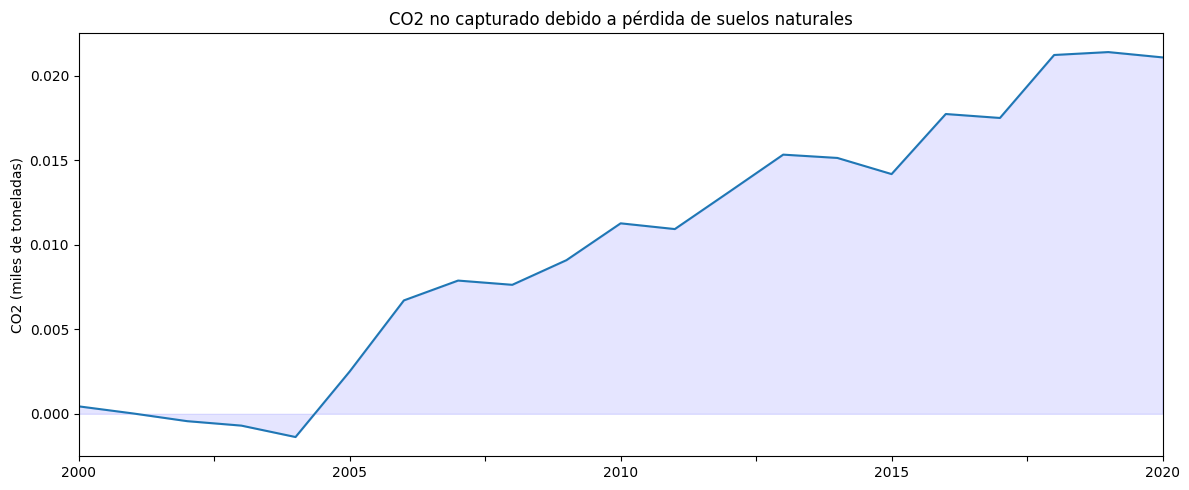

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
sequestration_oppportunity_cost.plot(ax=ax)
ax.set_xlabel("")
ax.set_ylabel("CO2 (miles de toneladas)")
ax.set_title("CO2 no capturado debido a pérdida de suelos naturales")
ax.fill_between(
    sequestration_oppportunity_cost.index,
    sequestration_oppportunity_cost,
    alpha=0.1,
    color="blue"
)
ax.set_xlim("2000", "2020")
# ax.set_ylim(0, 22)
fig.tight_layout()

/var/folders/yq/0mz24vy927s9m5vjh6gqb6040000gn/T/ipykernel_12907/708067544.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  areas.set_index("label").loc["settlements"][list(range(21))].plot(label="Área urbanizada", ax=ax, c="r")


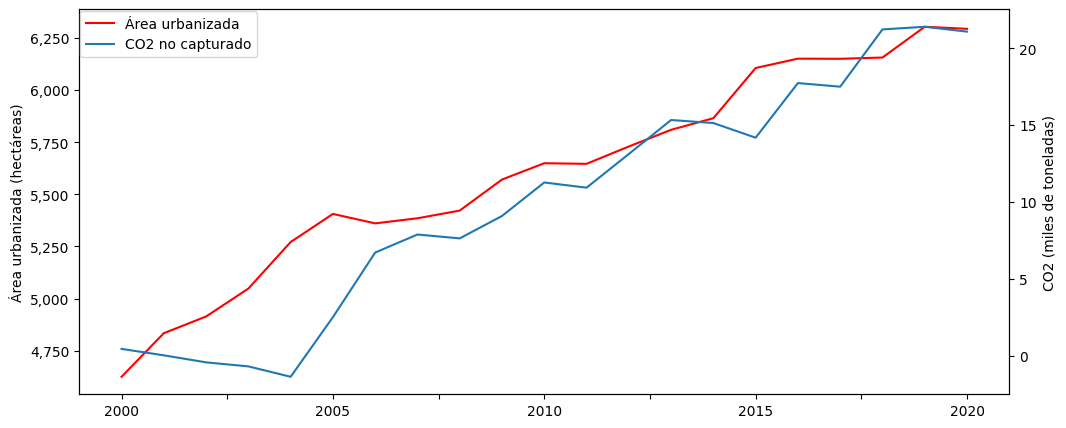

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
areas.set_index("label").loc["settlements"][list(range(21))].plot(label="Área urbanizada", ax=ax, c="r")

ax2 = ax.twinx()
sequestration_oppportunity_cost.multiply(1000).plot(label="CO2 no capturado", ax=ax2)

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

ax.set_ylabel("Área urbanizada (hectáreas)")
ax2.set_ylabel("CO2 (miles de toneladas)")

fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.89))

In [16]:
c1 = areas.set_index("label").loc["settlements"][list(range(21))].rename("urbanized_area_ha")
c1.index = c1.index.astype(int) + 2000

c2 = sequestration_oppportunity_cost.multiply(1000).rename("co2_not_captured_kt")
c2.index = c2.index.astype(int)

df_out = pd.concat([c1, c2], axis=1)
df_out.to_csv("./parallel.csv")

/var/folders/yq/0mz24vy927s9m5vjh6gqb6040000gn/T/ipykernel_12907/272743121.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  c1 = areas.set_index("label").loc["settlements"][list(range(21))].rename("urbanized_area_ha")
